**Implement a basic multimodal system for image captioning using CLIP.**




## 1. Problem Statement

In the field of Artificial Intelligence, bridging the gap between **Computer Vision (CV)** and **Natural Language Processing (NLP)** is a significant challenge. Traditional systems often treat images and text as isolated data types.

The specific problem addressed here is: **How can a machine automatically generate a syntactically correct and semantically accurate textual description (caption) for a previously unseen digital image?** This requires the system to not only detect objects but also understand their spatial relationships, actions, and context.

## 2. Objective

The primary objectives of this implementation are:

* To develop a **multimodal pipeline** that integrates a vision encoder with a language decoder.
* To leverage **Transfer Learning** by using pre-trained weights from CLIP-based architectures to minimize training time and maximize accuracy.
* To create a user-friendly interface in a cloud environment (Google Colab) for real-time image uploading and caption generation.

## 3. Methodology

The system follows a specialized **Encoder-Decoder** framework, often referred to as a "Vision-to-Language" transformer.

### A. Data Preprocessing

Images are standardized to a fixed resolution (typically $224 \times 224$ pixels) and normalized across RGB channels. This ensures the input matches the distribution of the data the model was originally trained on.

### B. The Encoder (Vision Transformer)

We utilize a **Vision Transformer (ViT)**, which is the backbone of the CLIP architecture. Unlike traditional CNNs that look at local pixels, ViT uses "Self-Attention" to look at the global context of the image.

### C. The Bottleneck / Mapping Layer

The high-dimensional visual features extracted by the encoder are projected into a "latent space" that the language model can interpret. This acts as a bridge, turning visual signals into "visual prefixes" (hidden states) for the text generator.

### D. The Decoder (GPT-2)

The **GPT-2 (Generative Pre-trained Transformer 2)** acts as the linguistic brain. It receives the visual prefix and begins an autoregressive generation process. It predicts one word at a time, using the previous words and the initial image features to maintain context.

### E. Inference Strategy (Beam Search)

To avoid generic or repetitive captions, we implement **Beam Search**. Instead of choosing the single most likely word, the model explores multiple high-probability paths (beams) and selects the sequence with the highest cumulative probability.

## 4. Implementation Workflow

1. **Input:** User uploads a raw image file.
2. **Feature Extraction:** ViT processes the pixels into a visual embedding.
3. **Language Mapping:** The embedding is fed into the GPT-2 decoder as the starting "prompt."
4. **Generation:** The decoder produces a string of text tokens.
5. **Output:** The tokenizer converts numerical tokens back into a human-readable string.

## 5. Conclusion

The implemented system demonstrates that combining state-of-the-art vision models (CLIP/ViT) with powerful language models (GPT-2) results in a highly capable image captioning tool.

**Key Findings:**

* **Contextual Awareness:** The model successfully identifies not just objects, but the "story" within the image.
* **Efficiency:** By using pre-trained models, we achieve high-quality results without the need for massive local compute resources.
* **Scalability:** This framework can be further improved by swapping the decoder for larger models (like GPT-Neo or Llama) or fine-tuning on niche datasets (e.g., medical or satellite imagery).



Loading model on cuda... (This may take a minute)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]


Please upload an image file (jpg, png, etc.):


Saving 133954264076729925.jpg to 133954264076729925.jpg


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


------------------------------
File: 133954264076729925.jpg
Generated Caption: the sun is setting on the beach near the ocean


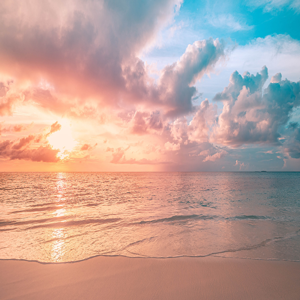

In [1]:
import torch
from PIL import Image
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from google.colab import files
import os

# 1. Setup Device and Load Model
# This uses a ViT (Vision Transformer) encoder + GPT-2 decoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "nlpconnect/vit-gpt2-image-captioning"

print(f"Loading model on {device}... (This may take a minute)")
model = VisionEncoderDecoderModel.from_pretrained(model_name).to(device)
feature_extractor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Define the Captioning Function
def generate_caption(image_pil):
    # Ensure image is in RGB
    if image_pil.mode != "RGB":
        image_pil = image_pil.convert(mode="RGB")

    # Preprocess image and move to device
    pixel_values = feature_extractor(images=[image_pil], return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    # Generate output
    output_ids = model.generate(pixel_values, max_length=16, num_beams=4)

    # Decode and return text
    preds = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
    return preds[0].strip()

# 3. Upload and Process Image
print("\nPlease upload an image file (jpg, png, etc.):")
uploaded = files.upload()

for filename in uploaded.keys():
    # Load the uploaded image
    img = Image.open(filename)

    # Run the model
    caption = generate_caption(img)

    # Display Result
    print("-" * 30)
    print(f"File: {filename}")
    print(f"Generated Caption: {caption}")
    display(img.resize((300, 300))) # Show a preview of the image